In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path

                                                                                                        
DATASET_DIR = Path("dataset")                                                                           
SPLITS = ["train", "valid", "test"]                                                                     
CLASSES = [str(i) for i in range(10)]    


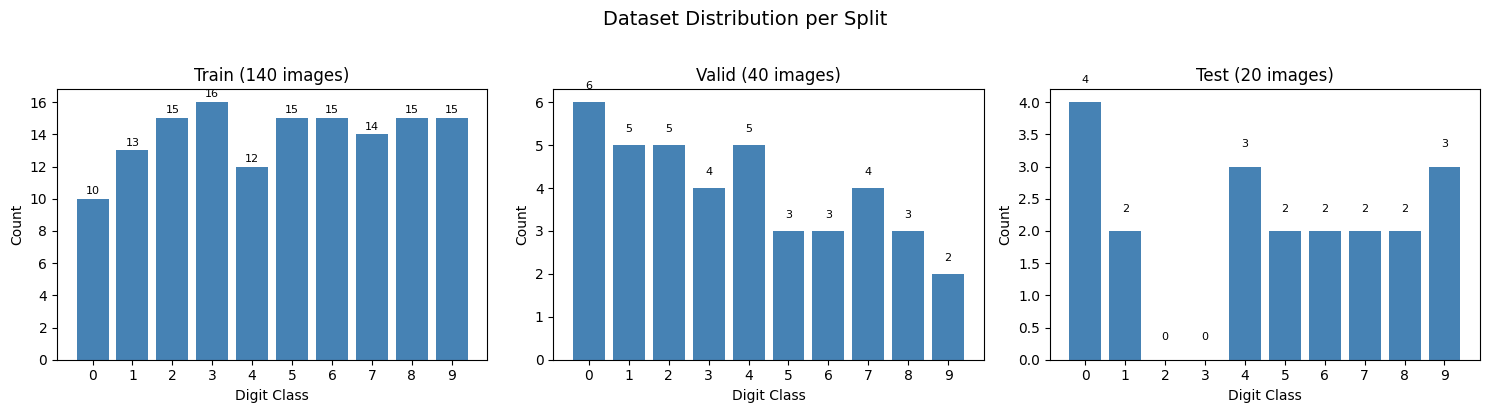

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
                                                                                    
for ax, split in zip(axes, SPLITS):                                             
      counts = []                                                                   
      for cls in CLASSES:                                                           
          folder = DATASET_DIR / split / cls
          n = len(list(folder.glob("*"))) if folder.exists() else 0
          counts.append(n)
      bars = ax.bar(CLASSES, counts, color="steelblue")
      ax.set_title(f"{split.capitalize()} ({sum(counts)} images)")
      ax.set_xlabel("Digit Class")
      ax.set_ylabel("Count")
      for bar, c in zip(bars, counts):
          ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                  str(c), ha="center", fontsize=8)

plt.suptitle("Dataset Distribution per Split", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

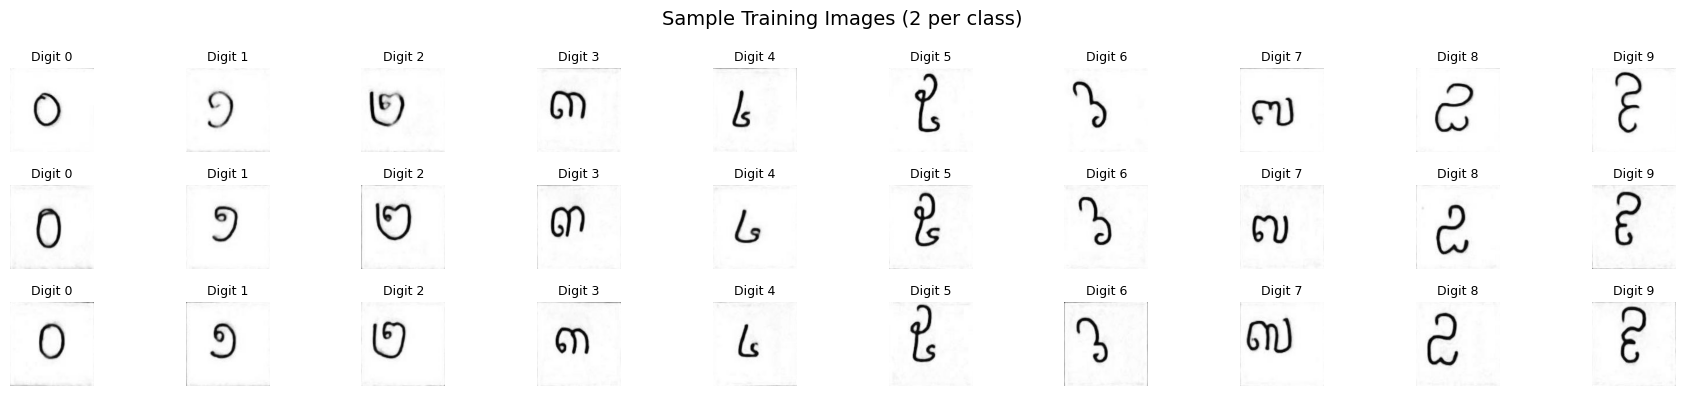

In [3]:

  # Cell 3 — Sample images (2 per class from train set)                             
  fig, axes = plt.subplots(3, 10, figsize=(18, 4))                                  
                                                                                    
  for col, cls in enumerate(CLASSES):                                               
      folder = DATASET_DIR / "train" / cls                                          
      images = sorted(folder.glob("*"))[:3]                                         
      for row, img_path in enumerate(images):
          img = mpimg.imread(str(img_path))
          axes[row, col].imshow(img, cmap="gray")
          axes[row, col].set_title(f"Digit {cls}", fontsize=9)
          axes[row, col].axis("off")

  plt.suptitle("Sample Training Images (2 per class)", fontsize=14)
  plt.tight_layout()
  plt.show()

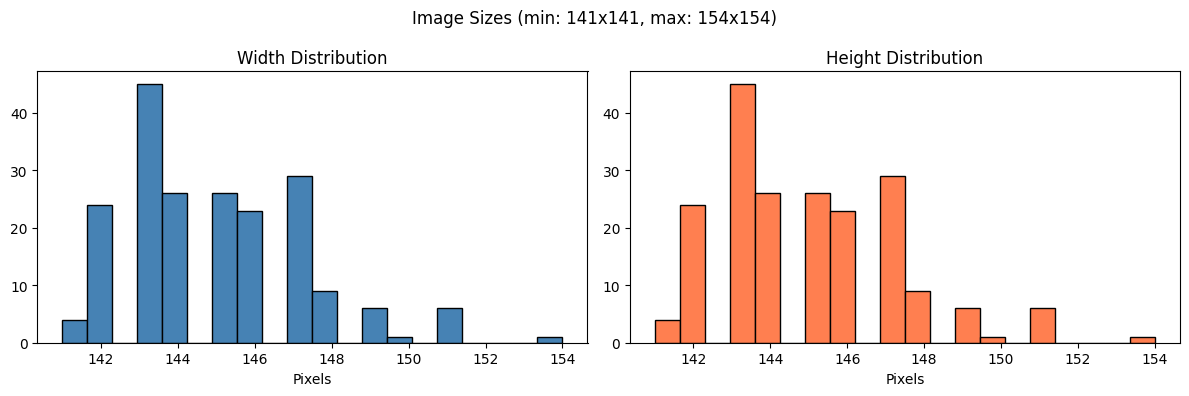

In [4]:
  # Cell 4 — Image size distribution                                                                      
  widths, heights = [], []
                                                                                                          
  for split in SPLITS:                                                                                  
      for cls in CLASSES:                                                                                 
          folder = DATASET_DIR / split / cls                                                              
          if not folder.exists():                                                                       
              continue
          for img_path in folder.glob("*"):
              img = mpimg.imread(str(img_path))
              h, w = img.shape[:2]
              widths.append(w)
              heights.append(h)

  fig, axes = plt.subplots(1, 2, figsize=(12, 4))
  axes[0].hist(widths, bins=20, color="steelblue", edgecolor="black")
  axes[0].set_title("Width Distribution")
  axes[0].set_xlabel("Pixels")

  axes[1].hist(heights, bins=20, color="coral", edgecolor="black")
  axes[1].set_title("Height Distribution")
  axes[1].set_xlabel("Pixels")

  plt.suptitle(f"Image Sizes (min: {min(widths)}x{min(heights)}, max: {max(widths)}x{max(heights)})",
  fontsize=12)
  plt.tight_layout()
  plt.show()


In [5]:
# Data Preprocessing & Augmentation 
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Image size & batch config
IMG_SIZE = 128
BATCH_SIZE = 16

  # Augmentation for training (helps with small dataset)
train_transform = transforms.Compose([
      transforms.Resize((IMG_SIZE, IMG_SIZE)),
      transforms.Grayscale(num_output_channels=1),
      transforms.RandomRotation(15),
      transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
      transforms.ToTensor(),
      transforms.Normalize([0.5], [0.5])
  ])

  # No augmentation for valid/test
eval_transform = transforms.Compose([
      transforms.Resize((IMG_SIZE, IMG_SIZE)),
      transforms.Grayscale(num_output_channels=1),
      transforms.ToTensor(),
      transforms.Normalize([0.5], [0.5])
  ])

  # Load datasets
train_dataset = datasets.ImageFolder(root="dataset/train", transform=train_transform)
valid_dataset = datasets.ImageFolder(root="dataset/valid", transform=eval_transform)
test_dataset  = datasets.ImageFolder(root="dataset/test",  transform=eval_transform)

  # DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

  # Verify
print(f"Train: {len(train_dataset)} images, {len(train_loader)} batches")
print(f"Valid: {len(valid_dataset)} images, {len(valid_loader)} batches")
print(f"Test:  {len(test_dataset)} images, {len(test_loader)} batches")
print(f"Classes: {train_dataset.classes}")

Train: 140 images, 9 batches
Valid: 40 images, 3 batches
Test:  20 images, 2 batches
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [17]:
# Design The model
import torch.nn as nn

class KhmerDigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block1
            nn.Conv2d(1,32, kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),  

            # Block2
            nn.Conv2d(32,64, kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2), 

            # Block3
            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3), 
        )
        #⏺ From the 3 MaxPool layers halving the image size each time:                                  
                                                                                               
        #Input:     128 x 128                                                                       
        #MaxPool 1: 128 / 2 = 64                                                                      
        #MaxPool 2:  64 / 2 = 32                                                                      
        #MaxPool 3:  32 / 2 = 16   ← this is where 16 comes from                                      
                                                               
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128 * 16*16,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,10)
        )
    
    def forward (self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
  # Cell 7 — Device Config & Model Init                                                      
  device = torch.device(                                                                       
      "cuda" if torch.cuda.is_available()                                                      
      else "mps" if torch.backends.mps.is_available()                                          
      else "cpu"                                                                               
  )
  model = KhmerDigitCNN().to(device)                                                           
  print(f"Device: {device}")                                                                 
  print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")                         
  print(model)  

Device: mps
Parameters: 8,484,554
KhmerDigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.3, inplace=False)
  )


In [ ]:
# Training Config
import torch.optim as optim

EPOCHS = 500
LR = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

def train_one_epoch():
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(train_loader), 100.0 * correct / total

In [28]:
  # Validation                                                                                 
  def validate():                                                                              
      model.eval()                                                                             
      running_loss, correct, total = 0.0, 0, 0                                                 
                                                                                               
      with torch.no_grad():                                                                    
          for images, labels in valid_loader:                                                  
              images, labels = images.to(device), labels.to(device)                            
              outputs = model(images)                                                          
              loss = criterion(outputs, labels)                                                

              running_loss += loss.item()
              _, predicted = outputs.max(1)
              total += labels.size(0)
              correct += predicted.eq(labels).sum().item()

      return running_loss / len(valid_loader), 100.0 * correct / total

In [29]:
# Run Training Loop
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch()
    valid_loss, valid_acc = validate()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
              f"Valid Loss: {valid_loss:.4f} Acc: {valid_acc:.1f}%")

Epoch [5/500] Train Loss: 0.8148 Acc: 65.0% | Valid Loss: 0.2166 Acc: 92.5%
Epoch [10/500] Train Loss: 0.7032 Acc: 72.1% | Valid Loss: 0.2084 Acc: 95.0%
Epoch [15/500] Train Loss: 0.8295 Acc: 67.1% | Valid Loss: 0.2032 Acc: 95.0%
Epoch [20/500] Train Loss: 0.7481 Acc: 76.4% | Valid Loss: 0.1995 Acc: 95.0%
Epoch [25/500] Train Loss: 0.7528 Acc: 75.0% | Valid Loss: 0.1946 Acc: 97.5%
Epoch [30/500] Train Loss: 0.7587 Acc: 71.4% | Valid Loss: 0.2014 Acc: 97.5%
Epoch [35/500] Train Loss: 0.8291 Acc: 69.3% | Valid Loss: 0.1827 Acc: 100.0%
Epoch [40/500] Train Loss: 0.5397 Acc: 79.3% | Valid Loss: 0.1819 Acc: 100.0%
Epoch [45/500] Train Loss: 0.7463 Acc: 74.3% | Valid Loss: 0.1837 Acc: 100.0%
Epoch [50/500] Train Loss: 0.7314 Acc: 75.0% | Valid Loss: 0.1784 Acc: 100.0%
Epoch [55/500] Train Loss: 0.7976 Acc: 75.0% | Valid Loss: 0.1740 Acc: 100.0%
Epoch [60/500] Train Loss: 0.7025 Acc: 73.6% | Valid Loss: 0.1634 Acc: 100.0%
Epoch [65/500] Train Loss: 0.7304 Acc: 76.4% | Valid Loss: 0.1627 Acc: 